# LNCU Tutorial Session 2: Burgers' Equation

## Overview

The Burgers' equation is a paradigmatic nonlinear partial differential equation defined with periodic boundary conditions in one-dimension as 
$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2} - u \frac{\partial u}{\partial x} ,\quad u(x,0) = u_0(x),
$$
where $u(x,t)$ is the fluid velocity at poisition $x$ and time $t$, $\nu$ is the diffusion coefficient and $u_0(x)$ is the initial condition.

Since the Burgers' equation is nonlinear, we embed it into a higher order linear system using the following transformations:
- Spatial discretization to transform the nonlinear PDE $\rightarrow$ nonlinear ODE.
- Carleman linearization to transform the finite, nonlinear ODE $\rightarrow$ infinite, linear ODE.
- Temporal discretization & truncation to transform the infinite, linear ODE $\rightarrow$ finite linear system of equations.

This results in the linear system $L^{(\text{e})}Y^{(\text{e})}=B^{(\text{e})}$, where

<div align="center">
<img src="Carleman.png" alt="Carleman Matrices" style="width: 60%; height: auto;">
</div>

and we assume that $B^{(\text{e})}$ is normalized for simplicity. 


We will solve this system using the following methods:
- The Carleman linear Burgers' equation is efficiently loaded onto quantum hardware using an LCNU approach.
- The initial conditions are loaded using qiskit's `StatePreparation` routine.
- The linear system is solved using the Variational Quantum Linear Solver (VQLS; BP2023).

We will end this tutorial by demonstrating that it is straightforward to scale the LCNU decomposition up with exponentially large number of spatial and temporal discretization points.

## Helpful References

- Gnanasekaran & Surana (2024). "Efficient variational quantum linear solver for structured sparse matrices" 
- Demirdjian & Hogancamp et al. (2026). "Quantum Data Loading for Carleman Linearized Systems: Application to the Lattice-Boltzmann Equation"
- Demirdjian & Quinn et al. (2026). "A Scalable Approach to Solve the Carleman Linearized Burgers' Equation on a Quantum Computer"
- Bravo-Prieto (2023). Variational quantum linear solver. Quantum, 7, 1188.
- Jennings (2025). An end-to-end quantum algorithm for nonlinear fluid dynamics with bounded quantum advantage, arXiv preprint arXiv:2512.03758.
- Khattar & Gidney (2025) Rise of conditionally clean ancillae for efficient quantum circuit constructions, Quantum 9, 1752.

In [ ]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile, qpy
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import GradientDescent, CG, L_BFGS_B
import platform
from qiskit.quantum_info import SparsePauliOp
import math

#Custom libs
import Burgers_utils as bu
import circuit_utils as cu
import misc_utils as mu
import Carleman_Dilation

## Parameters

Define physical parameters for the Burgers' equation and algorithmic parameters for solving the linear system.

Key parameters:
<div align="center">

| Variable | Description |
| -------- | -------- | 
| $n_x$ | Number of discrete spatial points |
| $n_t$ | Number of discrete temporal points |
| $\alpha$ | Carleman truncation order |
| $n_\text{layer}$ | Number of ansatz layers |

</div>


Note that the size of the matrix $L^{(\text{e})}$ is $2n_t n_x^\alpha$. Therefore, we can only solve very small systems in this demo. However, as will be shown, we can create the circuits for extremely large systems. 

In [15]:
#Parameters (each must be power of 2)
nx = 2**2 #number of spatial discretization points (>= 2**2)
nt = 2**1 #number of temporal discretization points
alpha = 2**1 #Carleman truncation order.
nqubit = int(np.log2(nt) + alpha*np.log2(nx) + 1 + 1) #Number of qubits to encode the Carleman matrix +1 for zero padding and +1 for ancilla

#Spatial parameters & initial condition
Length = 2*np.pi #units: [m]
dx   = Length/(nx-1)
ic_type = 'Gaussian'

#Temporal parameters
T = 5. #Total duration, units: [s]
dt = T/nt

#Diffusion coefficient
nu = 0.25  #[m^2/s]

#Ansatz Parameters
lAnsatz = 'Sim18Mod'
nlayer = 8 #Number of ansatz layers
if (lAnsatz=='Sim9Mod'):
    ntheta = nlayer * (nqubit-1)
elif (lAnsatz=='Sim18Mod'):
    ntheta = 2 * nlayer * (nqubit-1)

#Optimizer parameters
opt = 'L_BFGS_B' #'GradientDescent', 'CG', 'L_BFGS_B'

#Options
lValidate = True #Validate the circuits for generating the Carlman matrix
lTranspile = False #Transpile L^e circuits. Slow for larger circuits

#Set of parameters 
params = {'alpha':alpha,'nx':nx,'nt':nt,'nqubit':nqubit,
          'dt':dt,'dx':dx,'nu':nu,'nlayer':nlayer,
          'ntheta':ntheta,'Length':Length,'ic_type':ic_type,
          'opt':opt,'lTranspile':lTranspile}

print('Number of spatial grid points: nx = ',nx)
print('Number of temporal grid points: nt = ',nt)
print('Carleman truncation order: α = ', alpha)
print('Dimension of linear system: ', 2**(nqubit-1))
print('Number of ansatz layers: nlayer = ',nlayer)
print('Number of variational parameters: nθ = ',ntheta)
print('Initial condition type: ic_type = ',ic_type)
print('optimizer: opt = ',opt)

Number of spatial grid points: nx =  4
Number of temporal grid points: nt =  2
Carleman truncation order: α =  2
Dimension of linear system:  64
Number of ansatz layers: nlayer =  8
Number of variational parameters: nθ =  96
Initial condition type: ic_type =  Gaussian
optimizer: opt =  L_BFGS_B


## Create Circuits

Consider the LCNU $L^{(\text{e})} = \sum_{l=1}^{N_s} c_l L_l$, for complex coefficients $c_l$ and specific non-unitaries $L_l$.

Next, define $V(\vec{\theta})$ as an ansatz, which is a parameterizable circuit. 

Create the following:

<div align="center">

| Variable | Description |
| -------- | -------- | 
| `qc_carl` | List of circuits for all $L_l$ terms |
| `coeffs` | List of the $c_l$ coefficients |
| `qc_init` | Circuit for $B^{(\text{e})}$ |
| `qc_anz` | Ansatz circuit for $V(\vec{\theta})$ |

</div>

Following DQ2026, the number of terms in the LCNU of $L^{(\text{e})}$, which is sized $2n_tn_x^{\alpha} \times 2n_tn_x^{\alpha}$, is exactly $N_s=\frac{1}{2}(9\alpha^2 + \alpha + 8)$.
For $\alpha=2$ this gives $N_s=23$.

If `lValidate=True`, then we validate $L^{(\text{e})}$ from the circuits against its analytical form.


Validating that the LCNU circuits match the analytical matrix
Successful validation, error is  0.0


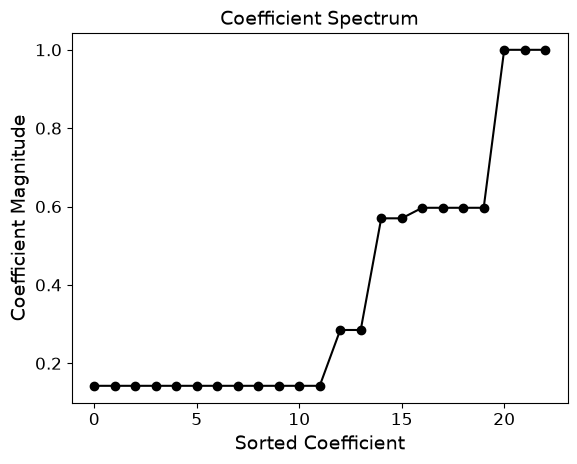

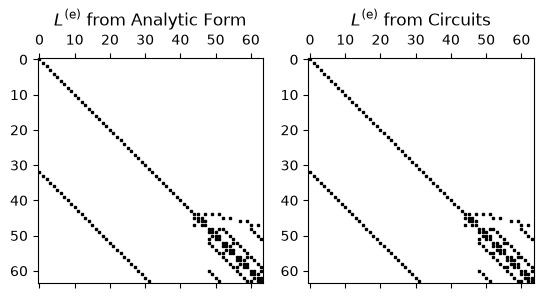

In [16]:
#Create the circuits and coefficients for the Carleman matrix
qc_carl,coeffs = bu.create_circs(params)
Ns = len(coeffs) #number of circuits
params['Ns'] = Ns

#Plot spectrum
fig, ax = plt.subplots()
p1 = ax.plot(sorted(np.abs(coeffs)),'-o',c='black')
plt.title('Coefficient Spectrum',fontsize=14)
plt.xlabel('Sorted Coefficient',fontsize=14)
plt.ylabel('Coefficient Magnitude',fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.savefig("Coefficients.png")

#Create Ansatz  
if (lAnsatz=='Sim9Mod'):
    qc_anz = cu.Ansatz_Sim9_Modified(params)
elif (lAnsatz=='Sim18Mod'):
    qc_anz = cu.Ansatz_Sim18Mod(params)

#Initial condition circuit
Be = np.asarray(mu.normalized_initial_condition(params),dtype=np.complex128) #normalized vector
if platform.system() == "Linux":
    Be[np.abs(Be) < 1e-14] = 0.0 # zero out tiny numerical noise
    Be = Be / np.linalg.norm(Be) # renormalize after thresholding
stateprep = StatePreparation(Be)
qc_init = QuantumCircuit(nqubit-1)
qc_init.append(stateprep, list(range(0,nqubit-1)))
qc_init = qc_init.decompose(reps=5)

#Ansatz transpilation 
simulator = AerSimulator()
qc_anz = transpile(qc_anz, simulator, optimization_level=3)

#Validate the circuits and coefficients by comparing the Carleman matrix generated from the circuits 
#with the Carleman matrix generated from matrices
if (nqubit <= 11 and lValidate):
    print('Validating that the LCNU circuits match the analytical matrix')
    Le_class,Le_circ = bu.validate_CarlemanDilated_Matrix(qc_carl,coeffs,params)

    #Plot exact approach versus circuit approach
    nA = np.sum([nx**i for i in range(1,alpha+1)])
    fig, ax = plt.subplots(1,2)
    p1 = ax[0].spy(Le_class, aspect = 'auto', markersize=2, alpha = 1.,c='black')
    p2 = ax[1].spy(Le_circ, aspect = 'auto', markersize=2, alpha = 1.,c='black')
    for axi in ax:
        axi.set_aspect('equal')
    ax[0].set_title(r'$L^{(\text{e})}$ from Analytic Form')
    ax[1].set_title(r'$L^{(\text{e})}$ from Circuits')
    plt.savefig("TestMatrix.png")

## Plot Carleman matrix

Now let's plot the Carleman matrix for different values of $n_x$, $n_t$, and $\alpha$ to get an understanding of what this matrix can look like. Note, keep $\alpha \le 4$ since the matrix dimension grows exponentially with $\alpha$. 

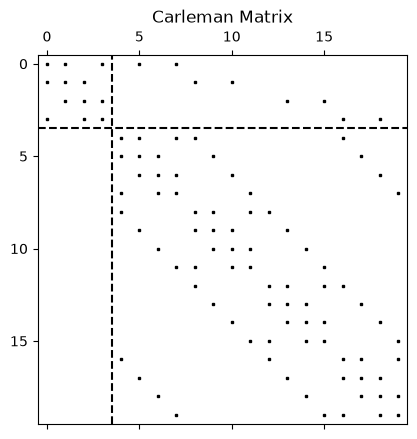

In [17]:
#Plot exact approach versus circuit approach
params0 = params.copy()
params0['nx'] = 2**2
params0['nt'] = 2**1
params0['alpha'] = 2**1 #<2**2 for memory reasons
bu.plot_CarlemanMatrix(params0)

## Exact circuits

The LCNU framework is used to create exact circuits down to the last gate.

As an example, below we print out the circuit for one of the 23 terms for the Carleman linearized Burgers' equation.

In [18]:
print(qc_carl[22])

               ┌───┐                                        
q_0: ──────────┤ X ├───────■─────────■──────────────────────
               └─┬─┘     ┌─┴─┐       │                      
q_1: ────────────┼───────┤ X ├──■────┼──────────────────────
                 │       └─┬─┘  │  ┌─┴─┐     ┌───┐          
q_2: ────────────┼─────────┼────┼──┤ X ├─────┤ X ├──■───────
                 │         │  ┌─┴─┐└─┬─┘┌───┐└─┬─┘  │       
q_3: ────────────┼─────────┼──┤ X ├──┼──┤ X ├──┼────■───────
          ┌───┐  │  ┌───┐  │  └─┬─┘  │  └─┬─┘  │    │  ┌───┐
q_4: ─────┤ X ├──┼──┤ X ├──┼────┼────┼────┼────┼────■──┤ X ├
     ┌───┐└─┬─┘  │  └───┘  │    │    │    │    │    │  ├───┤
q_5: ┤ X ├──┼────┼─────────┼────┼────┼────┼────┼────■──┤ X ├
     ├───┤  │    │         │    │    │    │    │  ┌─┴─┐└───┘
q_6: ┤ X ├──┼────┼─────────┼────┼────┼────┼────┼──┤ X ├─────
     └─┬─┘  │    │         │    │    │    │    │  └─┬─┘     
q_7: ──■────■────■─────────■────■────■────■────■────■───────
                        

## VQLS

The VQLS cost function is 
$$
C(\vec{\theta}) = \frac{1}{2} \left( 1 - \frac{1}{q}\frac{\sum_{k=0}^{q-1} \sum_{i,j=0}^{N_s-1} c_ic_j^*\delta_{i,j,k}}{\sum_{i,j=0}^{N_s-1} c_ic_j^*\beta_{i,j}}  \right),
\\[10pt]
\delta_{i,j,k} = \bra{V(\vec{\theta})} L_j^* U_b Z_k U_b^* L_i \ket{V(\vec{\theta})}, 
\\[10pt]
\beta_{i,j} = \bra{V(\vec{\theta})} L_j^* L_i \ket{V(\vec{\theta})},
$$
where each term is defined above and $Z_k$ is the Pauli-Z gate applied to the $k\text{th}$ qubit.

We use the following ansatz

<div align="center">
<img src="ansatz.png" alt="Ansatz" style="width: 60%; height: auto;">
</div>

### Store observables in cache

There are $qN_s^2\times$ $\delta_{i,j,k}$ circuits and $N_s^2\times$ $\beta_{i,j}$ circuits, resulting in a total of $N_s^2(q+1)$ circuits.

Since this is slow to run, we will store the following fixed observables in cache:

<div align="center">

| Variable | Description |
| -------- | -------- | 
| `obs_delta` | Defined as $L_j^* U_b Z_k U_b^* L_i$, which are the $\delta_{i,j,k}$ observables |
| `obs_beta` | Defined as $L_j^* L_i$, which are the $\beta_{i,j}$ observables |

</div>

In [19]:
#Store A_j^dagger U_bZ_kU_b^dagger A_i in cache
Aj = bu.extract_Aj_from_Uj(qc_carl,params)

#U_b Z_k U_b^dagger
UZUd = bu.extract_UZUd(qc_init,params) #Note: there is a bug in linux, so need to load results from windows system

obs_beta = 0
obs_delta = 0
coeffs_ij = []
coeffs_ijk = []
for i in range(0,Ns):
    for j in range(0,Ns):
        c = coeffs[i] * np.conjugate(coeffs[j])
        coeffs_ij.append(c) #ij
        obs_beta += c * Aj[j].conj().T @ Aj[i]
        for k in range(0,nqubit-1):
            coeffs_ijk.append(c) #ijk
            obs_delta += c * Aj[j].conj().T @ UZUd[k] @ Aj[i]
del([c])

### Run VQLS

Minimize the above cost function taking matrix products, which is mathematically equivalent to running the circuits but much faster.

Code will take ~2min with $n_x=4$, $n_t=2$, $\alpha=2$.

In [21]:
#Calculate cost function using cached matrices
thetas = np.random.uniform(0,np.pi,ntheta) #randomized parameters
backend = AerSimulator(method="statevector")
def calculate_cost_function(thetas):
    #update the variational parameters
    qc_anz0 = qc_anz.assign_parameters(thetas)
    qc_anz0.save_statevector()
    sv_anz = backend.run(qc_anz0).result().get_statevector().data

    #\beta_ij and \delta_ijk terms
    denom = np.vdot(sv_anz, obs_beta @ sv_anz)
    numer = np.vdot(sv_anz, obs_delta @ sv_anz)
    cost = 0.5*(1 - 1/(nqubit-1) * numer.real/denom.real)
    return(cost)

#callback to store the cost function at each iteration
cost_history = []
x_history = []
def store_intermediate_result(xk):
    x_history.append(xk.copy())
    val = calculate_cost_function(xk)
    cost_history.append(val)
    print(val)

#Optimizer parameters
nitr = 250
maxfun = 1e5 #15000
tol = 1e-5
gtol = 1e-4
eps = 1e-8
bounds = [(0, 2 * np.pi)] * params['ntheta']

if params['opt']=='CG':
    optimizer = CG(maxiter=nitr, tol=tol, gtol=gtol, callback=store_intermediate_result)
    theta_opt = optimizer.minimize(fun=calculate_cost_function, x0=thetas)
elif params['opt']=='L_BFGS_B':
    optimizer = L_BFGS_B(maxfun=maxfun,maxiter=nitr, eps=eps, ftol=tol, callback=store_intermediate_result)
    theta_opt = optimizer.minimize(fun=calculate_cost_function,x0=thetas,bounds=bounds)
elif params['opt']=='GradientDescent':
    optimizer = GradientDescent(maxiter=nitr, tol=tol, callback=store_intermediate_result)
    theta_opt = optimizer.minimize(fun=calculate_cost_function, x0=thetas)

print(theta_opt)


0.47434556702653446
0.41611150680516645
0.3774682800830227
0.34031601369478337
0.28542225315333225
0.2608010593271326
0.23535386341498682
0.21524180573578572
0.20075585295756665
0.193646189466124
0.18632631803269772
0.1807011273164199
0.17644288789758117
0.17496491240395268
0.17367914968211223
0.17259644666730406
0.1715255208208058
0.17062009547516882
0.16977558227234274
0.16924468079766541
0.16870306399754592
0.16836203848740455
0.1680888144776052
0.16779460202208374
0.16747653634250192
0.16719660614326765
0.16689304804777966
0.16659093299469463
0.1663318733896395
0.16588143477642847
0.16548153749277072
0.16493396097522578
0.1641664978658527
0.16352256948552912
0.1628275353425519
0.16165785417085804
0.16048610653100703
0.15860421567042243
0.15667359149950755
0.15288181568822706
0.15016150929422362
0.14567852372752205
0.1394460908586978
0.1344072821486758
0.13187602576255503
0.12946708082826064
0.12142239214520262
0.11249195968937098
0.10036148322715388
0.08928420146541433
0.0752285749

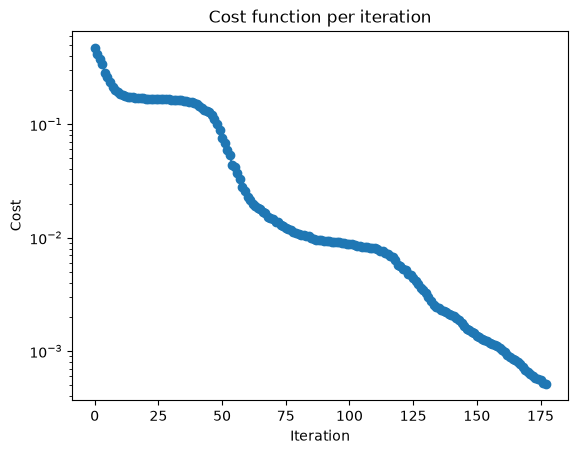

In [22]:
#Plot the cost function history
plt.plot(cost_history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost function per iteration")
plt.yscale('log')
plt.show()


c:\Users\demirdjian\Documents\IEEE_LCNU_Tutorial_Session2_2026\misc_utils.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  x_class[i,:] = x_class_full[offset:nx+offset]


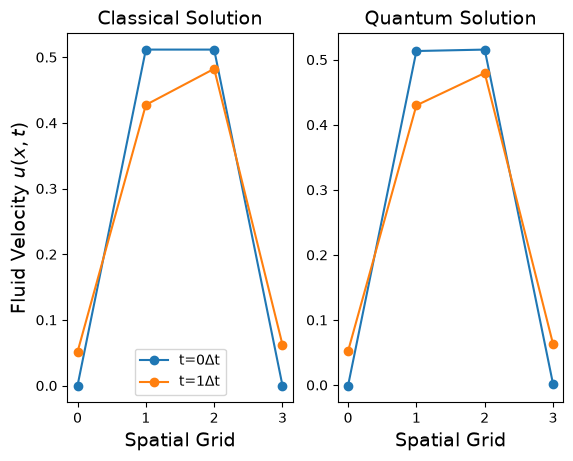

In [23]:
#Classical solution
Le_class = Carleman_Dilation.Carleman_Dilation_Matrix(params)
x_class = mu.solve_sys(Le_class,Be,params)

#Quantum solution obtained by evaluating the ansatz with optimized parameters
qc_anz0 = qc_anz.assign_parameters(theta_opt.x)
qc_anz0.save_statevector()
backend = AerSimulator(method="statevector")
job = backend.run(qc_anz0)
result = job.result()
sv_anz = result.get_statevector().data.real

#Extract quantum solution at each time step
x_qutm = np.zeros((nt,nx))
delta0 = np.sum([int(nx**j) for j in range(1,alpha+1)])
for i in range(nt):
    offset = int((i+1)*2*nx**alpha - delta0)
    x_qutm[i,:] = sv_anz[offset:nx+offset]
factor = 1 if np.sqrt(np.mean((x_qutm-x_class)**2)) < np.sqrt(np.mean((-x_qutm-x_class)**2)) else -1 #Sometimes solution is inverterd
x_qutm = factor * x_qutm

#Plot real solution with quantum solution
fig, ax = plt.subplots(1,2)
for i in range(0,nt):
    p1 = ax[0].plot(x_class[i,:],'-o',label=rf't={i}$\Delta$t')
    p2 = ax[1].plot(x_qutm[i,:],'-o')
ax[0].set_title("Classical Solution", fontsize=14)
ax[0].set_xlabel("Spatial Grid", fontsize=14)
ax[0].set_ylabel(r"Fluid Velocity $u(x,t)$", fontsize=14)
ax[1].set_title("Quantum Solution", fontsize=14)
ax[1].set_xlabel("Spatial Grid", fontsize=14)
ax[0].legend(loc='lower center')
plt.savefig("Solution.png")


## How does our LCNU method compare with a Pauli decomposition? 

To answer this question, we will compare the number of terms (NoT) in the the LCNU case with that of the Pauli decomposition case.

The NoT for the LCNU method was previously stated to be $N_s=\frac{1}{2}(9\alpha^2 + \alpha + 8)$. 

The NoT for the Pauli decomposition will be numerically calculated by 
- First, analytically forming the $L^{(\text{e})}$ matrix,
- Then, using qiskit's `SparsePauliOp.from_operator` function to decompose it using the Pauli decomposition. 

This process is repeated for different values of $n_x$ and $n_t$ with fixed $\alpha$. Ideally, we would also vary $\alpha$, but the system grows too rapidly for the qiskit's `SparsePauliOp.from_operator` to process. 



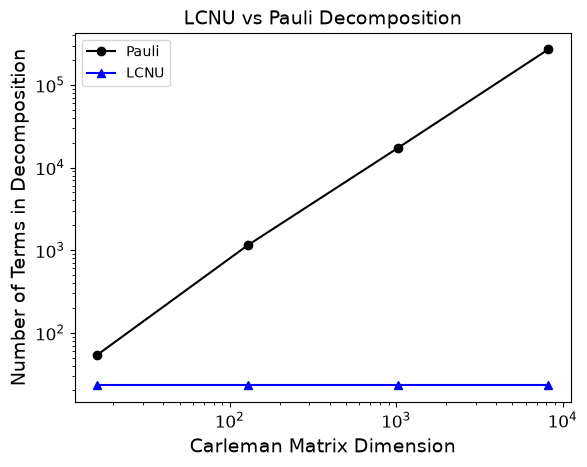

In [24]:
#Pauli
NoT_paul = [] #Number of terms in Pauli decomposition
NoT_lcnu = []
Le_dim = [] #Dimension of L^e matrix
params0 = params.copy()
for i in range(1,5):
    j = i if i<5 else 4
    params0['nt'] = 2**i
    params0['nx'] = 2**j
    Le = Carleman_Dilation.Carleman_Dilation_Matrix(params0)
    NoT_paul.append(SparsePauliOp.from_operator(Le).size)  
    Le_dim.append(2 * params0['nt'] * params0['nx']**params0['alpha'] ) #Dimension of Carleman matrix

    #Number of terms in LCNU
    NoT_lcnu.append((9*params0['alpha']**2 + params['alpha'] + 8)/2)

#Plots
fig, ax = plt.subplots()
ax.plot(Le_dim,NoT_paul,'-o',c='black',label='Pauli')
ax.plot(Le_dim,NoT_lcnu,'-^',c='blue',label='LCNU')

plt.xlabel("Carleman Matrix Dimension",fontsize=14)
plt.ylabel("Number of Terms in Decomposition",fontsize=14)
plt.title("LCNU vs Pauli Decomposition",fontsize=14)
ax.legend(loc='upper left')
ax.set_yscale('log') 
ax.set_xscale('log') 
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.savefig("PauliDecomp.png")

### T gate cost using a fault tolerant algorithm

As before, let $L^{(\text{e})} = \sum_{l=1}^{N_s} c_l L_l$. Assume that each non-unitary $L_l$ is embeded into a unitary $U_l$. Then the associated PREP and SELECT block encoding circuit takes the following form:

<div align="center">
<img src="PrepSelect.png" alt="PREP & SEL" style="width: 50%; height: auto;">
</div>

Here, we analyze the cost to block encode the LCNU decomposition using the PREP and SELECT. 

First, let $G[U]$ be defined as the T gate cost to implement an arbitrary unitary gate $U$. 

Following Jennings et al. (2025), we have $G[C^kU] = 14(k-1) + G[CU]$ and requiring $k-1$ ancilla qubits. Therefore, the T gate cost of the above SELECT operator is
$$
G[\sum_{l=0}^{N_s-1} C^{\log N_s} U_l]
=
14N_s(\log(N_s)-1) + \sum_{l=0}^{N_s-1} G[CU_l].
$$

We assume the T cost of the SELECT operator dominates the PREP operator.

Below, we use Pennylane's ``qp.estimator`` function to get a T gate estimate from our circuits. Unfortunately, this function does not recognize qiskit's ``MCX`` gate class, so we also assume that a $C^kX$ gate for $k>2$ requires $8k-12$ T gates and 2 clean ancilla qubits following Khattar and Gidney (2025). 

Lastly, we will also calculate $c=\sum_{l=1}^{N_s} |c_l|$ as we scale up. Following our LCNU, we have 
$$
\sum_{l=1}^{N_s} |c_l| 
=
 3 + \frac{\nu \Delta t}{\Delta x^2} \left( \frac{5}{2}\alpha(\alpha+1)+1 \right) + \frac{\Delta t}{\Delta x}\alpha(\alpha-1)
$$

To ensure that $c \not\rightarrow \infty$ as $\Delta x \rightarrow 0$, set $\Delta t \sim \Delta x^2$. This is achieved by setting $n_t=n_x^2$.

Below we calculate the T cost by fixing $\alpha=4$ and varying $n_x$ from $2^{10}$ to $2^{50}\approx 10^{15}$ and $n_t$ from from $2^{20}$ to $2^{100}\approx 10^{30}$.

This will take ~1min to run.

In [25]:
#Get the circuit depths as a function of nx and nt for fixed alpha
params_ridiculous = params.copy()
alpha_fixed = 2**2
params_ridiculous['alpha'] = alpha_fixed
params_ridiculous['nu'] = 1e-6 #Diffusion coefficient [m^2/s]
matrix_dim_nxnt = []
T_count_nxnt = []
labels = []
coeffs_L1norm = []
for i in range(10,60,10):
    print(f'Working on $n_x=2**{i},n_t=2**{2*i}$')
    params_ridiculous['nx'] = 2**i
    params_ridiculous['nt'] = params_ridiculous['nx']**2
    params_ridiculous['dx'] = Length/(params_ridiculous['nx']-1)
    params_ridiculous['dt'] = T/params_ridiculous['nt']
    params_ridiculous['nqubit'] = int(math.log2(params_ridiculous['nt']) + params_ridiculous['alpha']*math.log2(params_ridiculous['nx']) + 1 + 1)
    circs,coeffs = bu.create_circs(params_ridiculous)
    coeffs_L1norm.append(np.sum(np.abs(coeffs)))
    results = cu.estimate_circuits(circs)
    N_s = len(circs)
    offset = 14 * N_s*(np.log2(N_s)-1)
    T_count_nxnt.append(offset + sum(result["total_t_count"] for result in results))
    matrix_dim_nxnt.append(2**(params_ridiculous['nqubit']-1)) #Matrix dimension of the associated Carleman linearized system
    labels.append(rf"$(2^{{{i}}},2^{{{2*i}}})$")
labels[-1] = rf"$(n_x,n_t)=(2^{{{i}}},2^{{{2*i}}})$" #add to the last one


Working on $n_x=2**10,n_t=2**20$
Working on $n_x=2**20,n_t=2**40$
Working on $n_x=2**30,n_t=2**60$
Working on $n_x=2**40,n_t=2**80$
Working on $n_x=2**50,n_t=2**100$


## Exact circuits

As before, we are making the exact circuits!

In [31]:
part = cu.circuit_slice(circs[len(circs)-1], 100, 150)
print(part)


                                                                               »
  q_0: ────X───────────────────────────────────────────────────────────────────»
           │                                                                   »
  q_1: ─X──X───────────────────────────────────────────────────────────────────»
        │  │                                                                   »
  q_2: ─X──┼───────────────────────────────────────────────────────────────────»
        │  │                                                                   »
  q_3: ─┼──┼───────────────────────────────────────────────────────────────────»
        │  │                                                                   »
  q_4: ─┼──┼───────────────────────────────────────────────────────────────────»
        │  │                                                                   »
  q_5: ─┼──┼───────────────────────────────────────────────────────────────────»
        │  │                

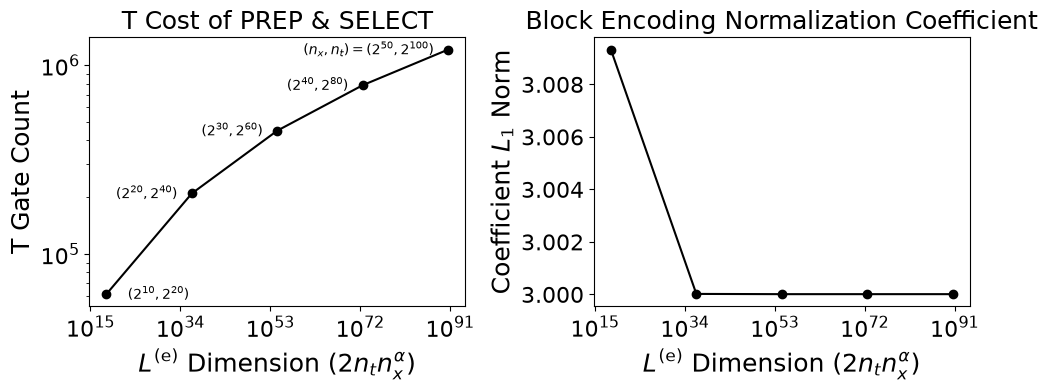

In [33]:
#Plot circuit depths
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(matrix_dim_nxnt,T_count_nxnt,'-o',c='black')
ax[0].set_xlabel(r"$L^{(\text{e})}$ Dimension ($2n_tn_x^\alpha$)",fontsize=18)
ax[0].set_ylabel(r"T Gate Count",fontsize=18)
ax[0].set_title('T Cost of PREP & SELECT',fontsize=18)
ax[0].set_xscale('log') 
ax[0].set_yscale('log') 
ax[0].tick_params(axis='x', labelsize=16)
ax[0].tick_params(axis='y', labelsize=16)
for i,(xi, yi, label) in enumerate(zip(matrix_dim_nxnt, T_count_nxnt, labels)):
    if i==0:
        ax[0].annotate(label,(xi,yi),xytext=(60, 6),textcoords="offset points",ha="right",va="top")
    else:
        ax[0].annotate(label,(xi,yi),xytext=(-10, 6),textcoords="offset points",ha="right",va="top")

ax[1].plot(matrix_dim_nxnt,coeffs_L1norm,'-o',c='black')
ax[1].set_xlabel(r"$L^{(\text{e})}$ Dimension ($2n_tn_x^\alpha$)",fontsize=18)
ax[1].set_ylabel(r"Coefficient $L_1$ Norm",fontsize=18)
ax[1].set_title('Block Encoding Normalization Coefficient',fontsize=18)
ax[1].set_xscale('log') 
ax[1].tick_params(axis='x', labelsize=16)
ax[1].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.savefig("Max_circ_depth.png")



## Conclusions

In this tutorial, we have done the following:
- Created LCNU circuits for the 1D Carleman linearized Burgers' equation,
- Solved the Carleman linearized system using VQLS,
- Shown that the LCNU decomposition outperforms the Pauli decomposition,
- Proven that the LCNU approach can efficiently load the 1D Carleman Burgers' equation as $n_x$ and $n_t$ are scaled up exponentially. 

While we focused in this tutorial on the 1D Burgers' equation since it is straight forward, it is worth noting that these methods have been applied to real-world problems like the 3D lattice-Boltzmann equation (see DH2026).


Final note: while we demonstrated an efficient loading method, it is important to point out that this does *not* mean that we have a full end-to-end quantum algorithm to obtain a solution. To do that, we would need to not only do preconditioning on $L^\text{(e)}$, but we would also need to determine what information to extract from the final state. 